### Importieren von Play package

In [1]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import Play
import mesmer
import model
import cartopy.crs as ccrs

xr.set_options(keep_attrs=True, display_expand_data=False)
np.set_printoptions(threshold=10, edgeitems=2)



#### Update nach änderung im Pythonfile

In [4]:
#Update Module
importlib.reload(Play.plot_one_var)
importlib.reload(Play.mask)

<module 'Play.mask' from '/home/pjunghans/BachelorArbeit/Play/mask.py'>

#### Mask in Play ausprobieren 

In [5]:
data_set = Play.shape_data.show_data_set("mrsol")
data_set_masked = Play.mask.mask_dataholes(data_set)


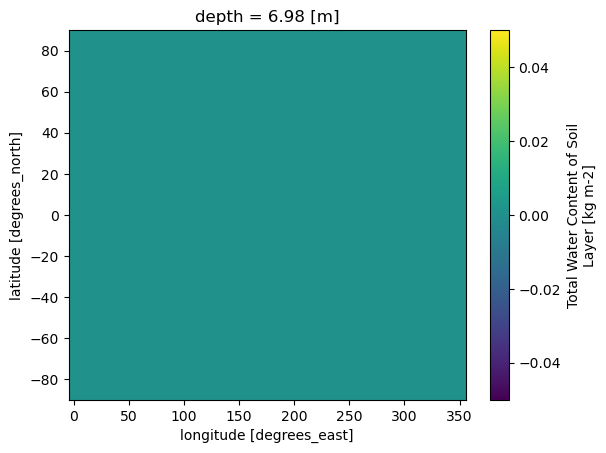

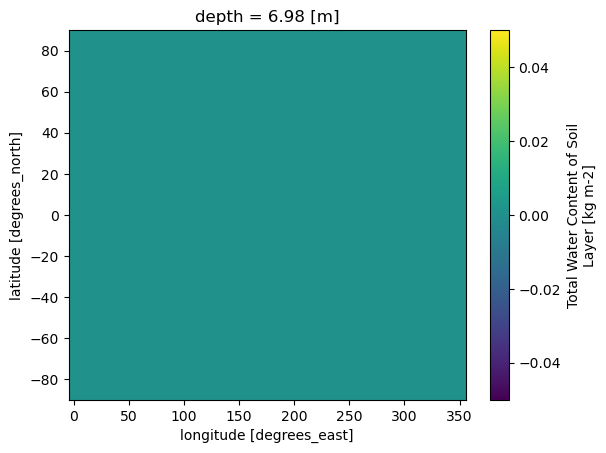

In [4]:
d = 4

((data_set["mrsol"].isel(depth = d) > 1e-4).all(dim = "time").astype(int)- (data_set_masked["mrsol"].isel(depth = d) > -100).any(dim = "time").astype(int)).plot()
plt.show()

(data_set["mrsol"].isel(depth = d) - data_set_masked["mrsol"].isel(depth = d)).sum(dim="time").plot()



#### Coastline Hintergründe

In [15]:
data_set = Play.shape_data.show_data_set("mrsol")
data_arr = data_set["mrsol"]
d = 1


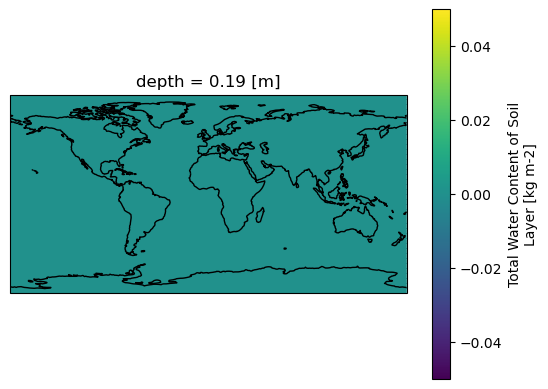

In [16]:
fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()}
)

((data_arr.isel(depth=d) <= 0).any(dim="time").astype(int)
 - (data_arr.isel(depth=d) <= 0).all(dim="time").astype(int)
).plot(ax=ax)

ax.coastlines()

plt.show()

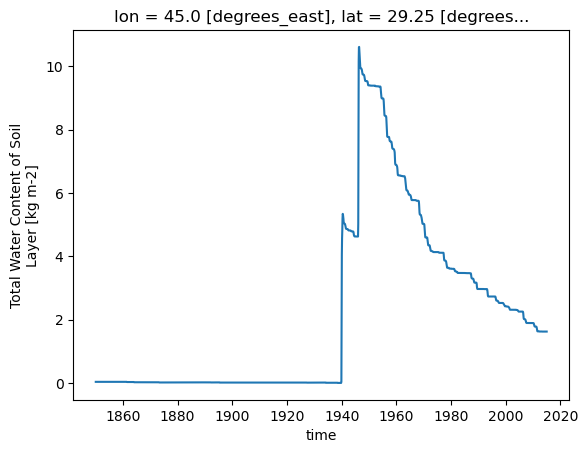

In [8]:
data_arr[:,3,26,5].plot()

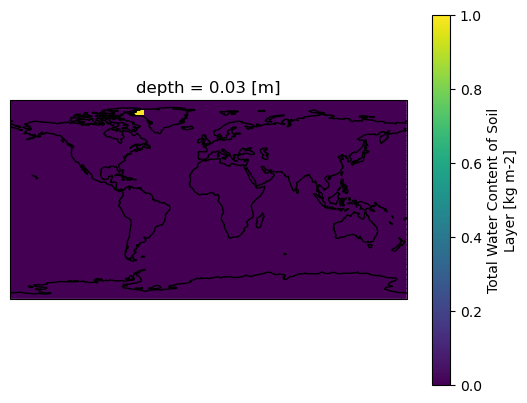

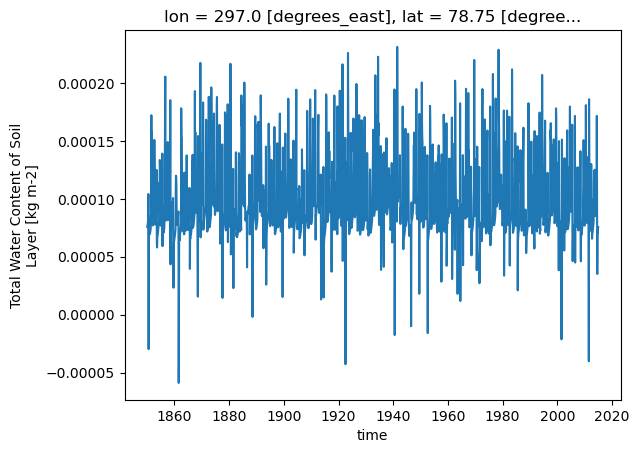

In [13]:
data_set = Play.shape_data.show_data_set("mrsol")
data_arr = data_set["mrsol"]
d = 0

fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()}
)

mask = ((data_arr.isel(depth=d) <= 0).any(dim="time").astype(int)
 - (data_arr.isel(depth=d) <= 0).all(dim="time").astype(int)
)
mask.plot(ax=ax)

ax.coastlines()

plt.show()


for y, x in zip(*np.where(mask)):

    data_arr[:,d,y,x].plot()
    plt.show()

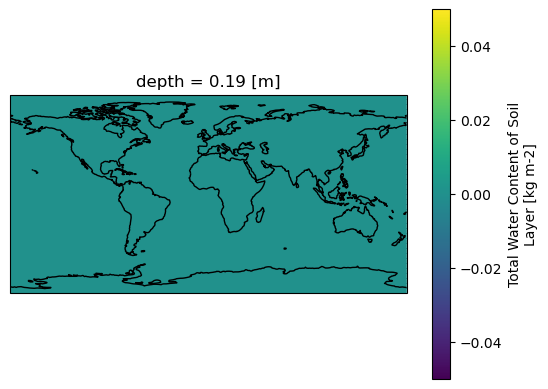

In [14]:
data_set = Play.shape_data.show_data_set("mrsol")
data_arr = data_set["mrsol"]
d = 1

fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()}
)

mask = ((data_arr.isel(depth=d) <= 0).any(dim="time").astype(int)
 - (data_arr.isel(depth=d) <= 0).all(dim="time").astype(int)
)
mask.plot(ax=ax)

ax.coastlines()

plt.show()


for y, x in zip(*np.where(mask)):

    data_arr[:,d,y,x].plot()
    plt.show()

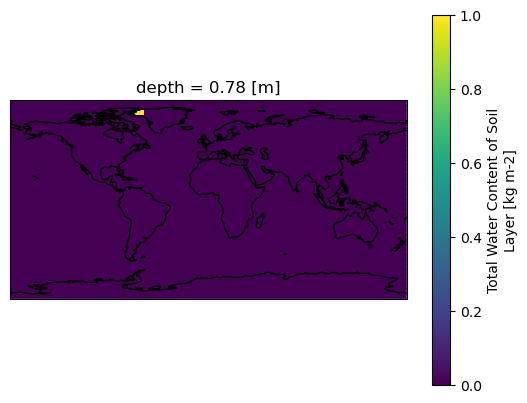

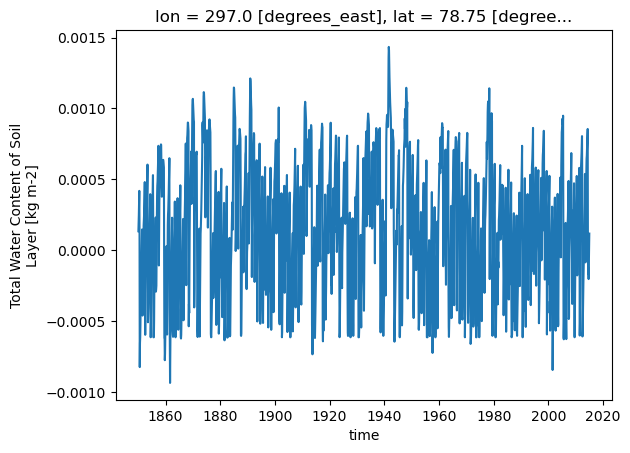

In [17]:
data_set = Play.shape_data.show_data_set("mrsol")
data_arr = data_set["mrsol"]
d = 2

fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()}
)

mask = ((data_arr.isel(depth=d) <= 0).any(dim="time").astype(int)
 - (data_arr.isel(depth=d) <= 0).all(dim="time").astype(int)
)
mask.plot(ax=ax)

ax.coastlines()

plt.show()


for y, x in zip(*np.where(mask)):

    data_arr[:,d,y,x].plot()
    plt.show()

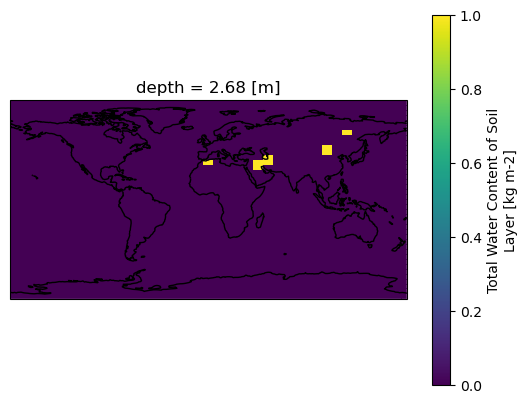

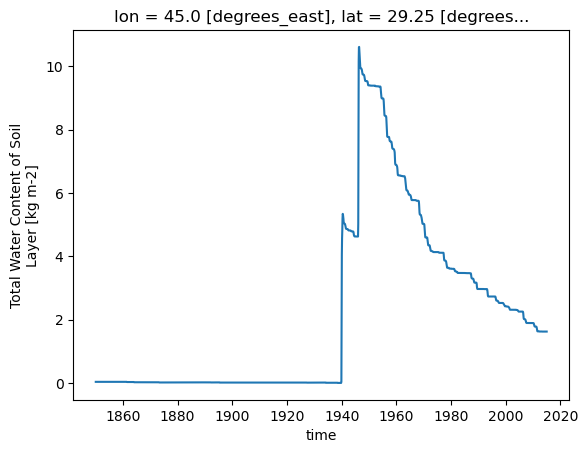

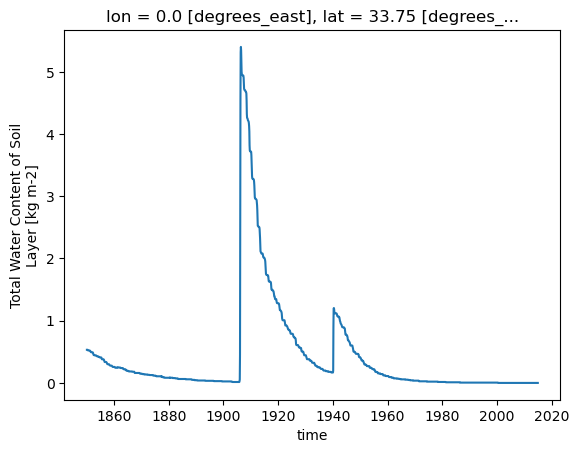

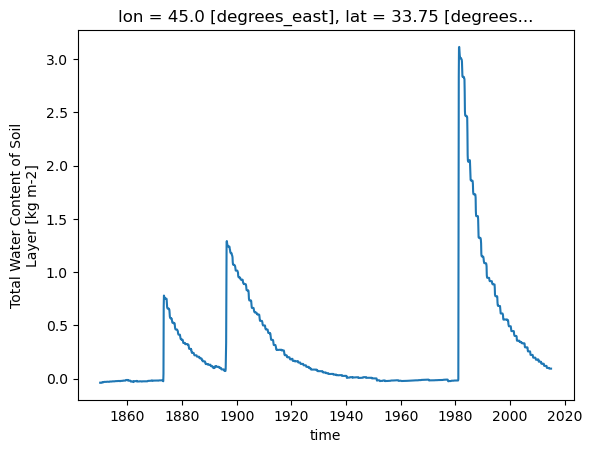

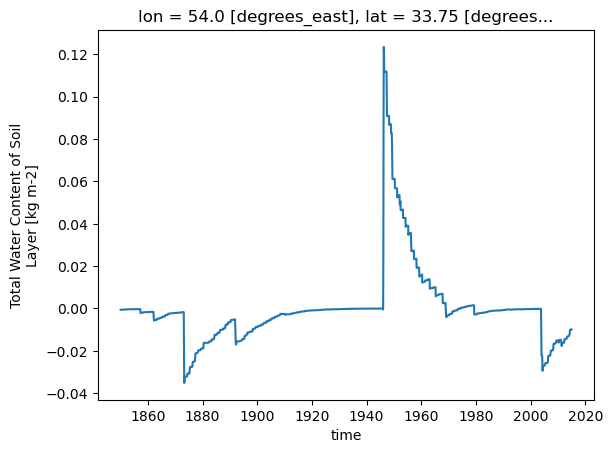

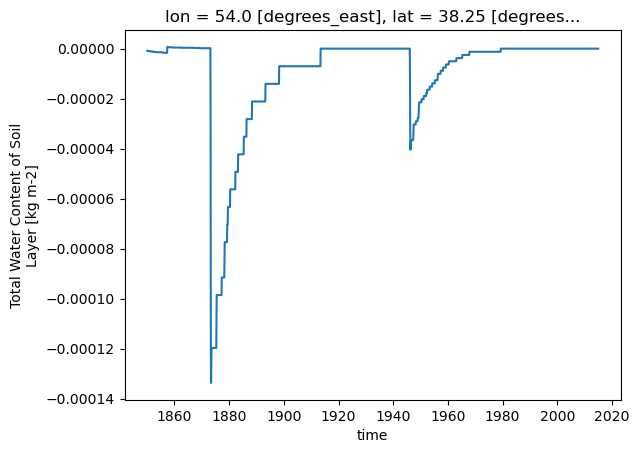

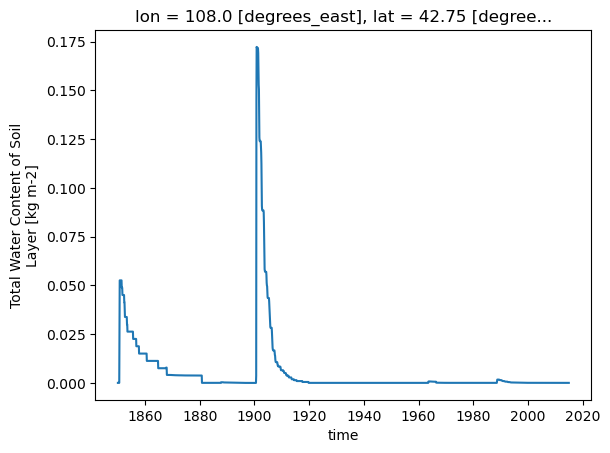

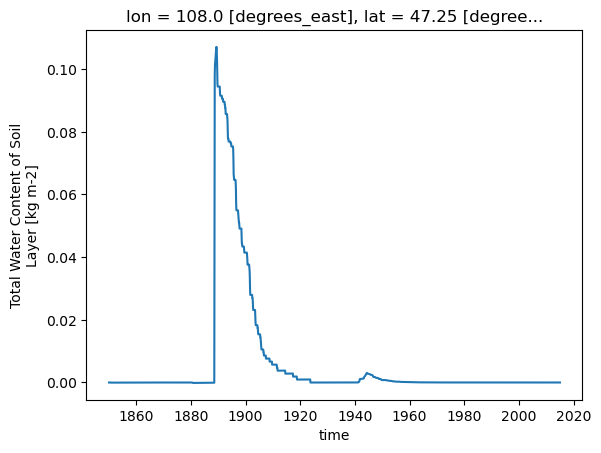

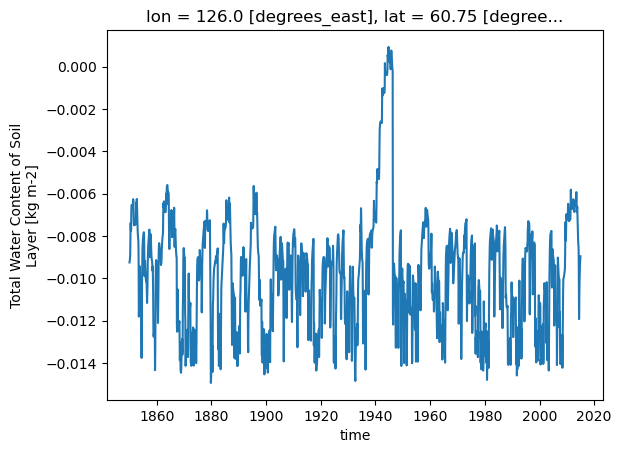

In [19]:
data_set = Play.shape_data.show_data_set("mrsol")
data_arr = data_set["mrsol"]
d = 3

fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()}
)

mask = ((data_arr.isel(depth=d) <= 0).any(dim="time").astype(int)
 - (data_arr.isel(depth=d) <= 0).all(dim="time").astype(int)
)
mask.plot(ax=ax)

ax.coastlines()

plt.show()


for y, x in zip(*np.where(mask)):

    data_arr[:,d,y,x].plot()
    plt.show()

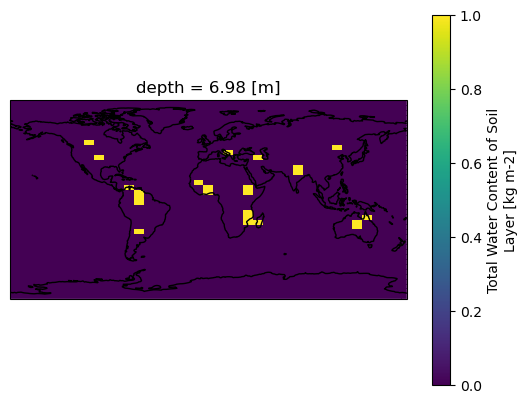

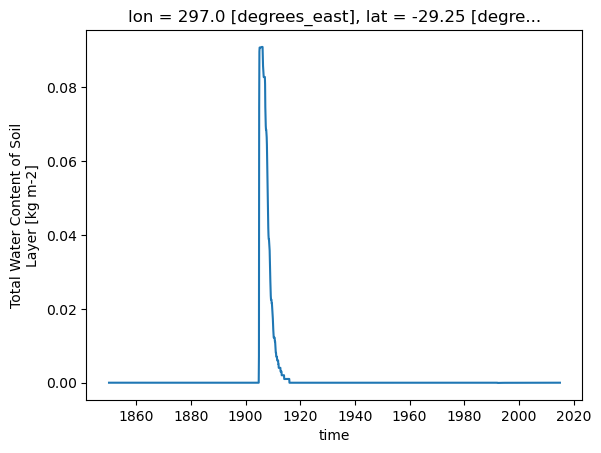

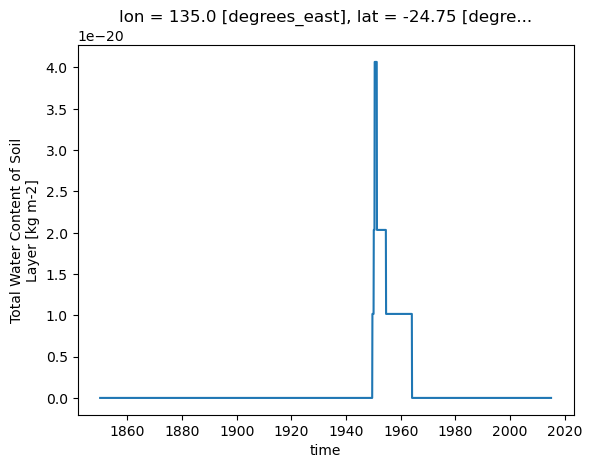

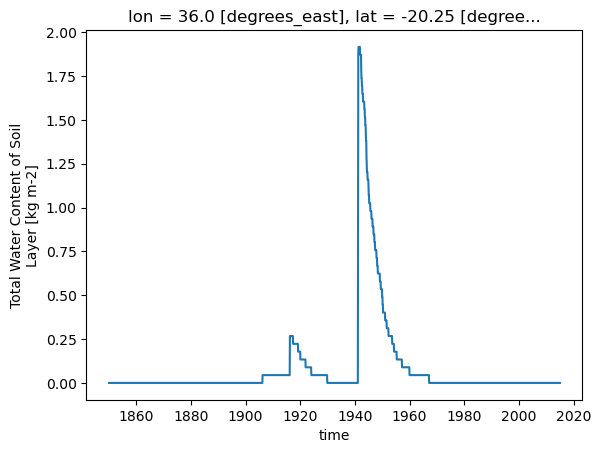

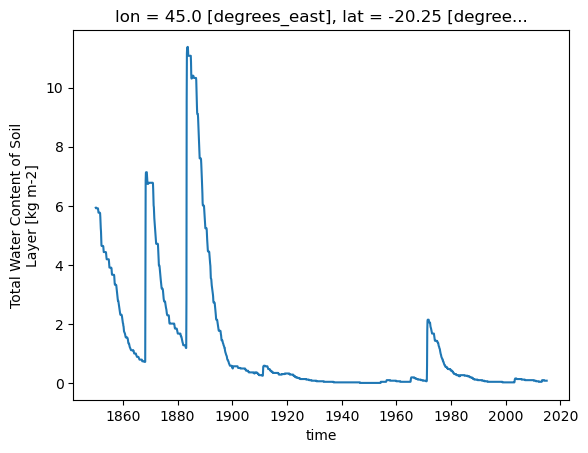

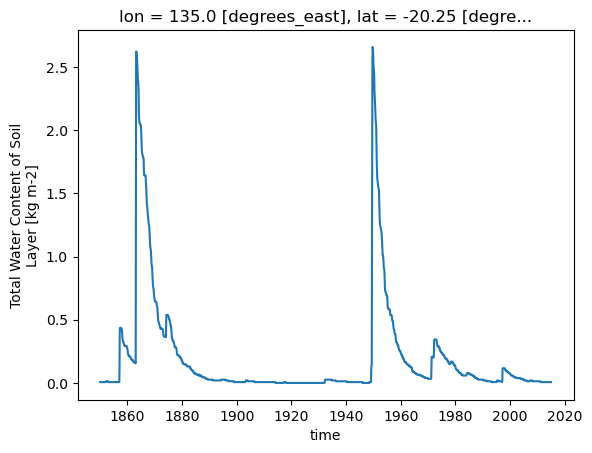

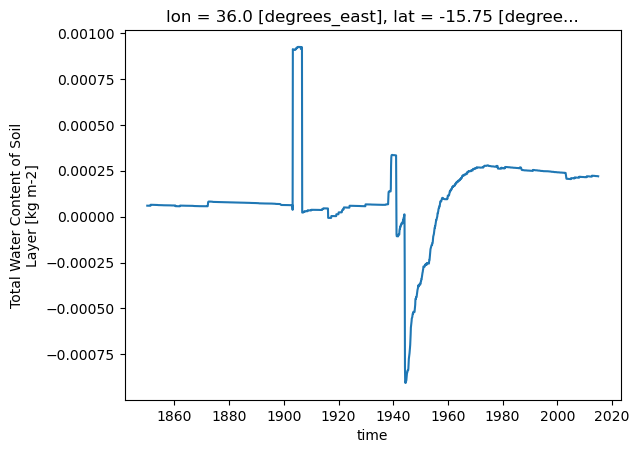

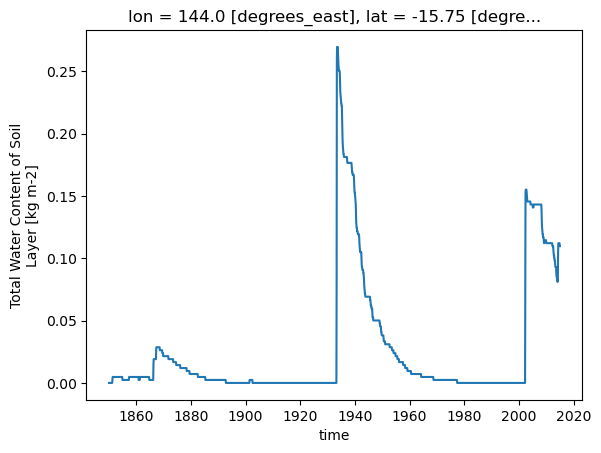

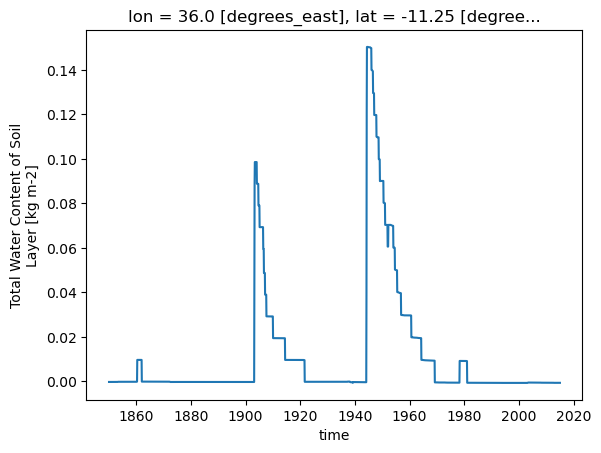

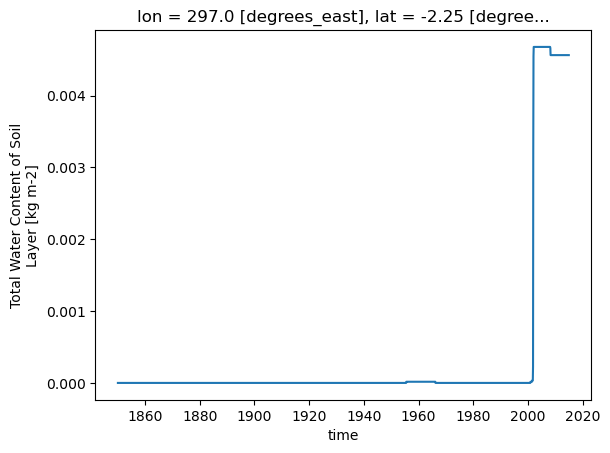

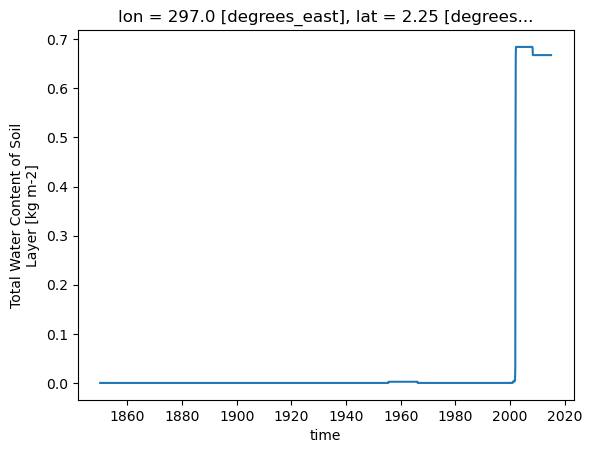

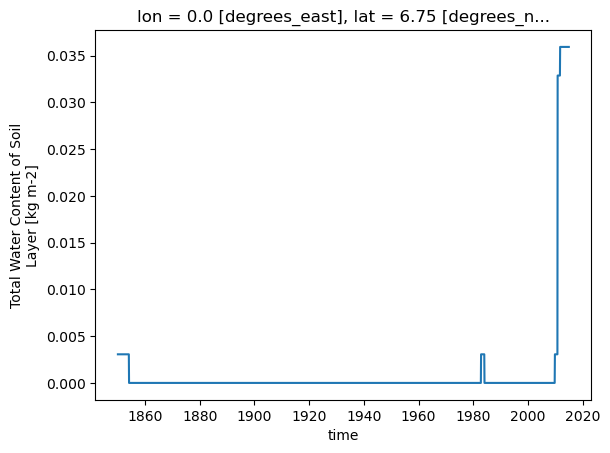

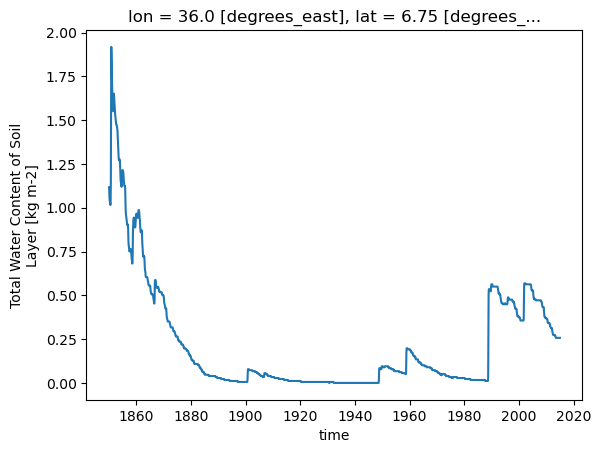

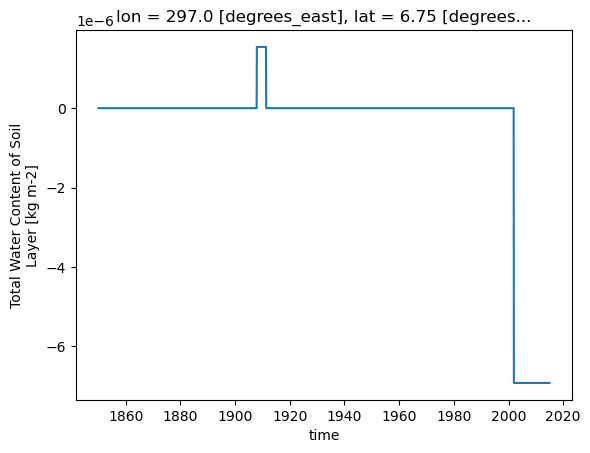

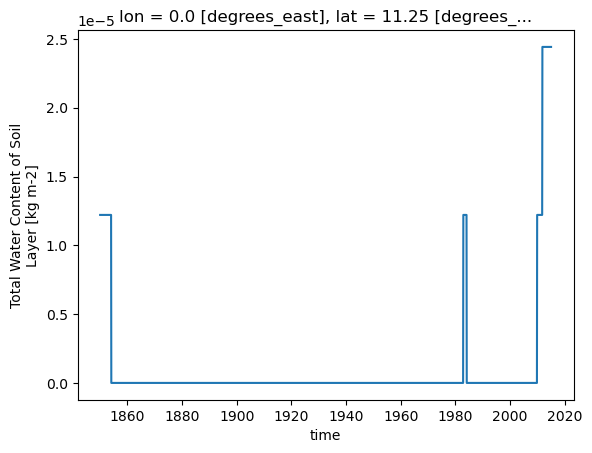

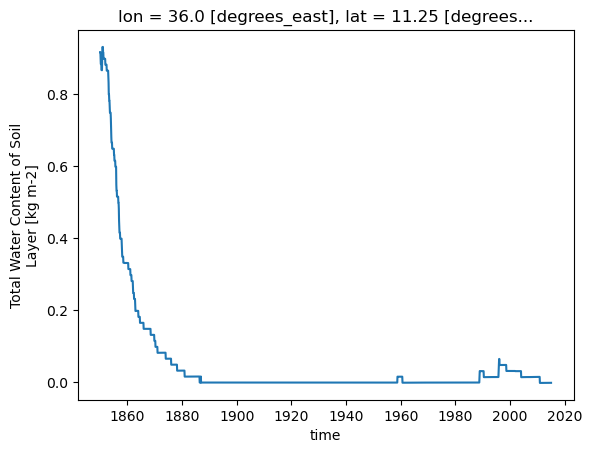

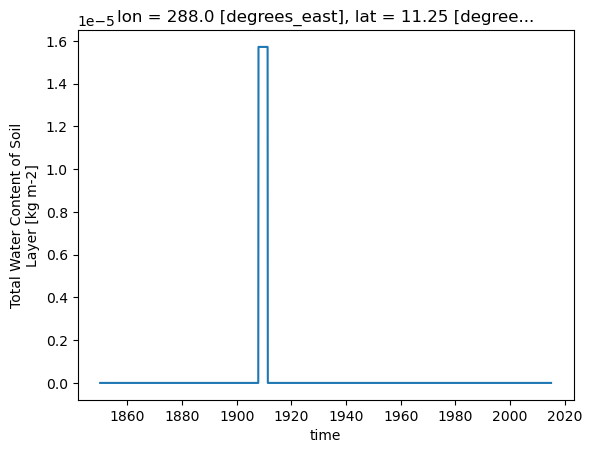

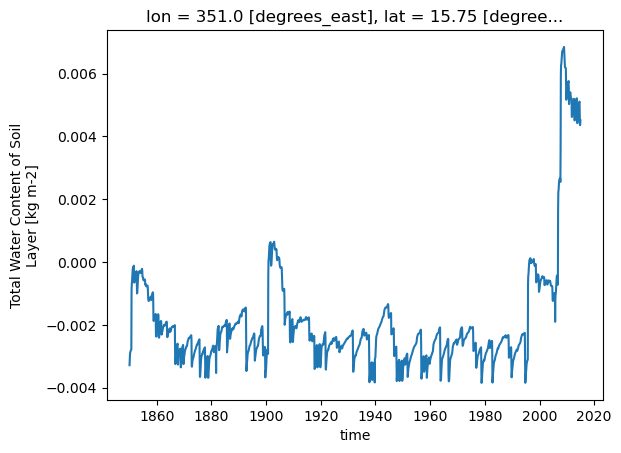

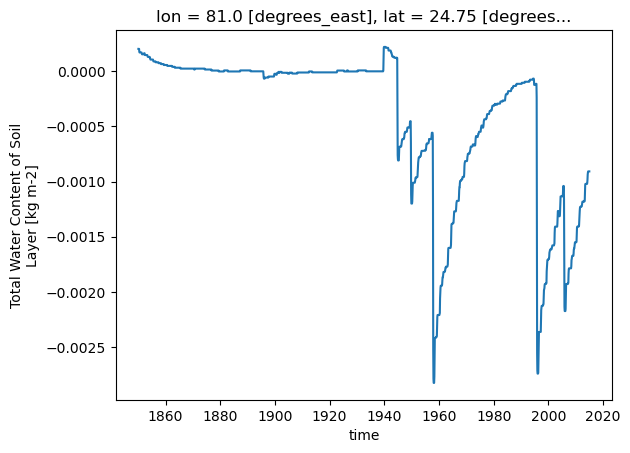

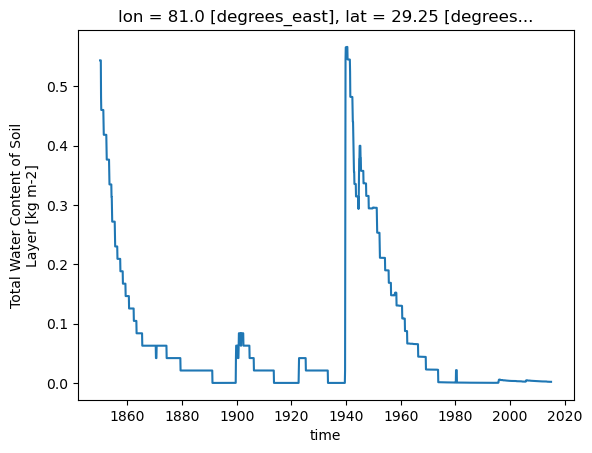

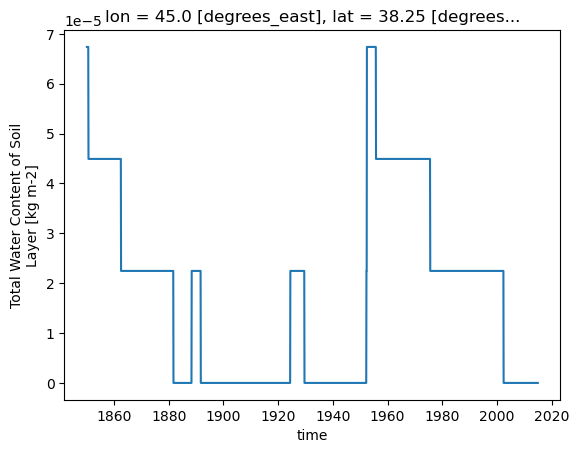

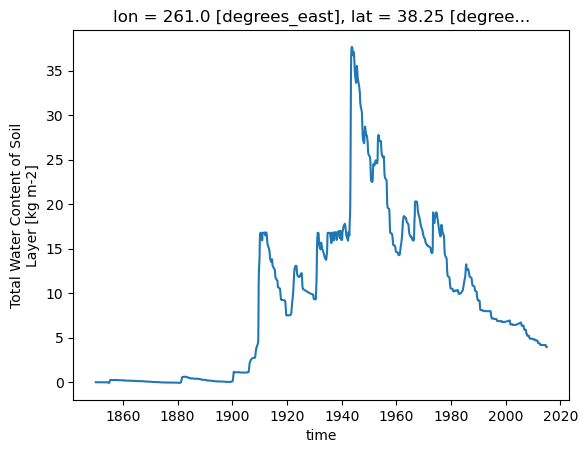

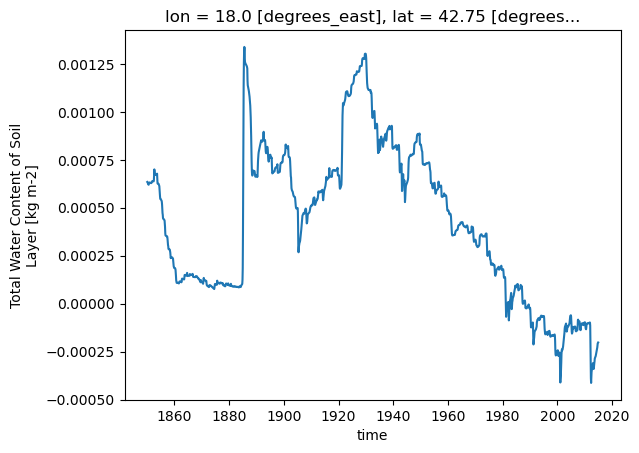

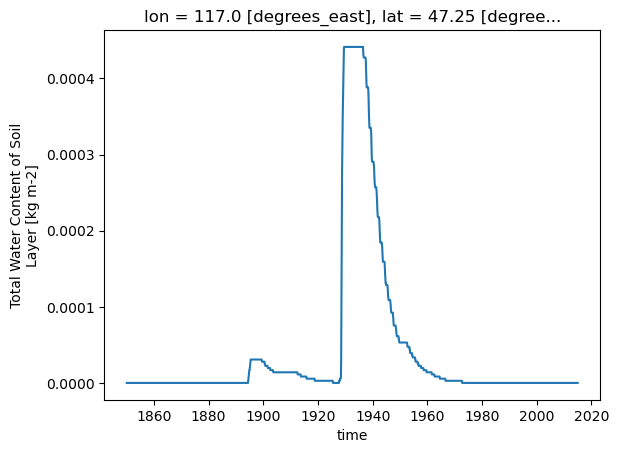

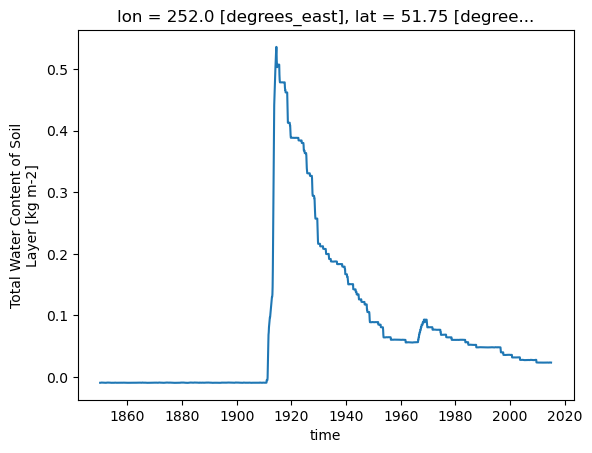

In [20]:
data_set = Play.shape_data.show_data_set("mrsol")
data_arr = data_set["mrsol"]
d = 4

fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()}
)

mask = ((data_arr.isel(depth=d) <= 0).any(dim="time").astype(int)
 - (data_arr.isel(depth=d) <= 0).all(dim="time").astype(int)
)
mask.plot(ax=ax)

ax.coastlines()

plt.show()


for y, x in zip(*np.where(mask)):

    data_arr[:,d,y,x].plot()
    plt.show()

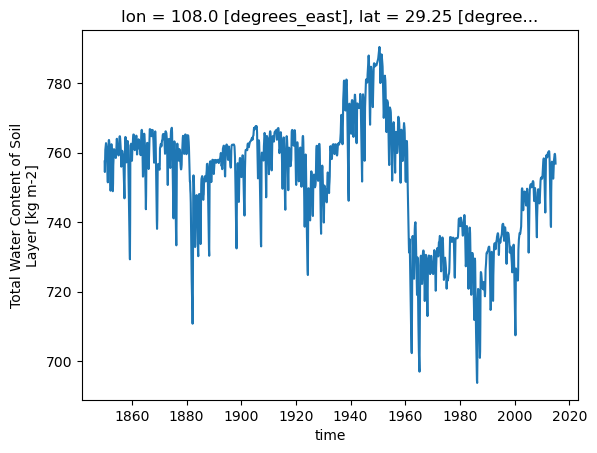

In [30]:
data_arr[:,4,26,12].plot()

### Mask in model Ausprobieren

In [2]:
importlib.reload(model.mask)

<module 'model.mask' from '/home/pjunghans/BachelorArbeit/model/mask.py'>

In [3]:
data_set = Play.shape_data.show_data_set("mrsol")
data_set_masked , mask= model.mask.mask_nonpositivs(data_set)
data_set_chunk_masked , chunk_mask= model.mask.mask_nonpositiv_height_chunks(data_set)

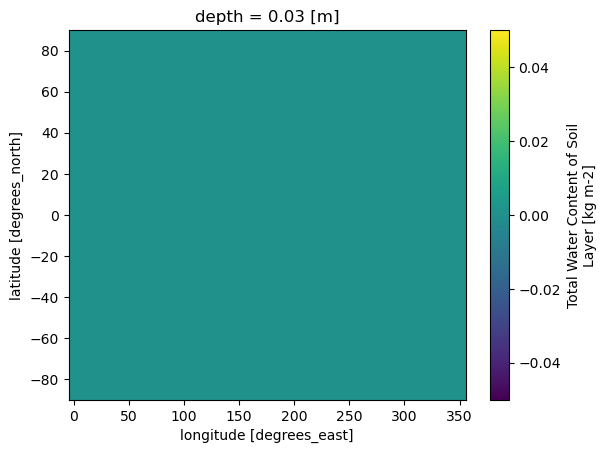

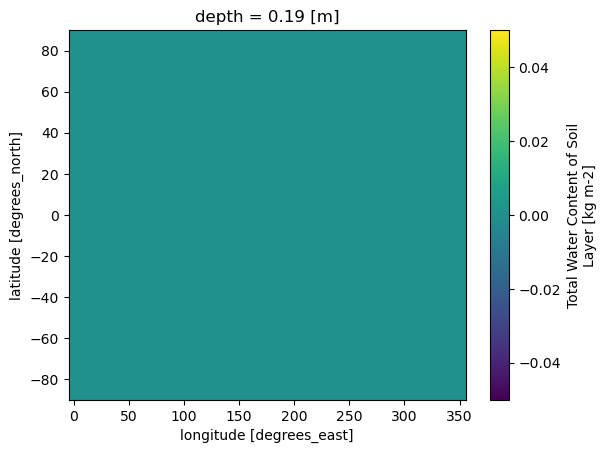

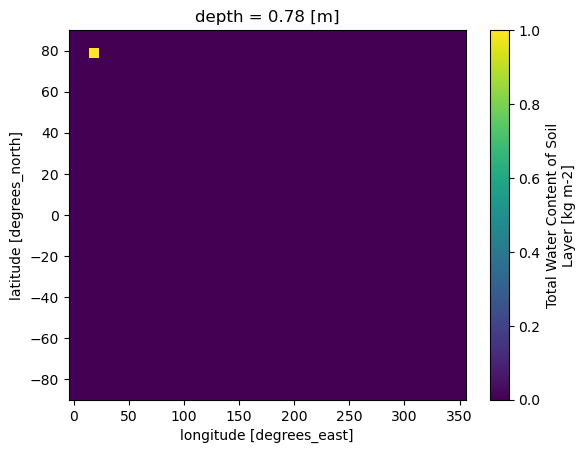

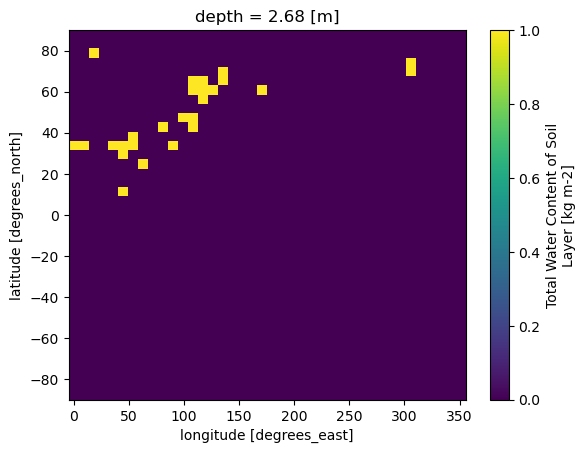

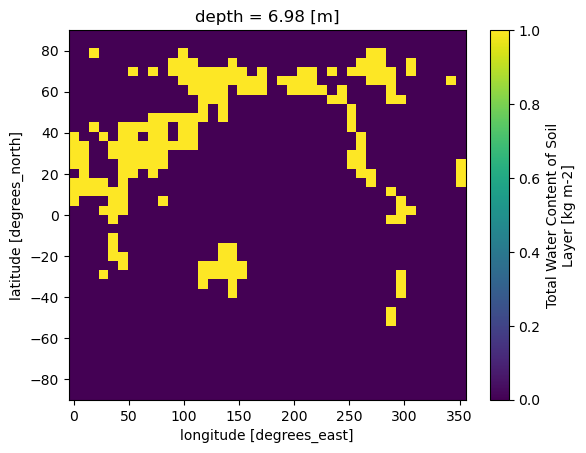

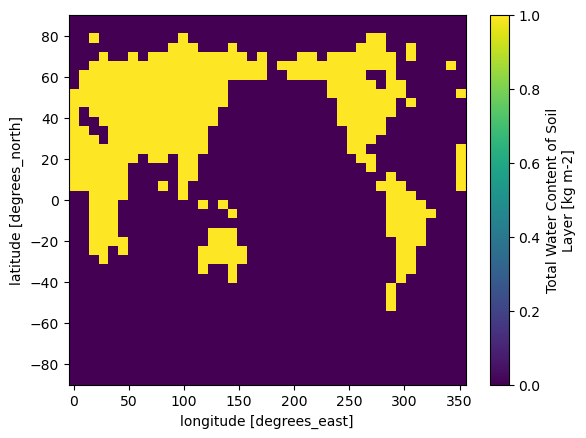

In [4]:
(chunk_mask.astype(int) - mask.isel(depth = 0).astype(int)).plot()
plt.show()
(chunk_mask.astype(int) - mask.isel(depth = 1).astype(int)).plot()
plt.show()
(chunk_mask.astype(int) - mask.isel(depth = 2).astype(int)).plot()
plt.show()
(chunk_mask.astype(int) - mask.isel(depth = 3).astype(int)).plot()
plt.show()
(chunk_mask.astype(int) - mask.isel(depth = 4).astype(int)).plot()
plt.show()
chunk_mask.plot()

In [8]:
(data_set_chunk_masked.mrsol <= 1e-4).sum()

<xarray.DataArray 'mrsol' ()> Size: 8B
406041
Attributes:
    standard_name:  mass_content_of_water_in_soil_layer
    long_name:      Total Water Content of Soil Layer
    units:          kg m-2
    comment:        in each soil layer, the mass of water in all phases, incl...
    original_name:  mrsol
    cell_methods:   area: mean where land time: mean
    cell_measures:  area: areacella
    history:        2019-09-11T14:22:11Z altered by CMOR: Reordered dimension...